# Extended Kalman Filter

A nonlinear filter for 2D vehicle localization, fusing GPS, IMU (yaw rate,
longitudinal acceleration), and wheel speed. The vehicle is modeled with a
**Constant Turn Rate and Acceleration (CTRA)** motion model — nonlinear in
the heading $\psi$ and turn rate $\dot\psi$, so we linearize it on every
prediction step (that's the "Extended" part).

Dataset: `2014-03-26-000-Data.csv` — 50 Hz IMU/wheel data with GPS interleaved
at ~10 Hz.


## State and motion model

State (six components):

$$
\mathbf{x} = \begin{bmatrix}
x \\ y \\ \psi \\ v \\ \dot\psi \\ a
\end{bmatrix}
\;=\;
\begin{bmatrix}
\text{east position [m]} \\
\text{north position [m]} \\
\text{heading [rad]} \\
\text{speed [m/s]} \\
\text{yaw rate [rad/s]} \\
\text{long. acceleration [m/s}^2\text{]}
\end{bmatrix}
$$

Under constant turn rate and acceleration over a step $\Delta t$, the closed-form
update is

$$
\begin{aligned}
x_{t} &= x_{t-1} + \frac{v_{t-1}}{\dot\psi_{t-1}}\bigl(\sin(\psi_{t-1} + \dot\psi_{t-1}\Delta t) - \sin\psi_{t-1}\bigr) \\
y_{t} &= y_{t-1} + \frac{v_{t-1}}{\dot\psi_{t-1}}\bigl(-\cos(\psi_{t-1} + \dot\psi_{t-1}\Delta t) + \cos\psi_{t-1}\bigr) \\
\psi_{t} &= \psi_{t-1} + \dot\psi_{t-1}\Delta t \\
v_{t} &= v_{t-1} + a_{t-1}\Delta t \\
\dot\psi_{t} &= \dot\psi_{t-1} \\
a_{t} &= a_{t-1}
\end{aligned}
$$

When $|\dot\psi| \to 0$ the curve formula blows up, so we fall back to the
straight-line limit $x_t = x_{t-1} + v\,\Delta t\,\cos\psi$ in that case.


## EKF recursion

The EKF replaces the linear $F$ and $H$ of the Kalman filter with **Jacobians**
$J_A$ and $J_H$ evaluated at the current state estimate:

$$
J_A = \left.\frac{\partial g}{\partial \mathbf{x}}\right|_{\hat{\mathbf{x}}_{t-1}}, \qquad
J_H = \left.\frac{\partial h}{\partial \mathbf{x}}\right|_{\hat{\mathbf{x}}_{t}}.
$$

The recursion is otherwise identical to the linear Kalman filter:

$$
\begin{aligned}
\hat{\mathbf{x}}_{t \mid t-1} &= g(\hat{\mathbf{x}}_{t-1 \mid t-1}) \\
P_{t \mid t-1} &= J_A\, P_{t-1 \mid t-1}\, J_A^{\top} + Q \\[4pt]
\mathbf{y}_t &= \mathbf{z}_t - h(\hat{\mathbf{x}}_{t \mid t-1}) \\
S_t &= J_H\, P_{t \mid t-1}\, J_H^{\top} + R \\
K_t &= P_{t \mid t-1}\, J_H^{\top}\, S_t^{-1} \\
\hat{\mathbf{x}}_{t \mid t} &= \hat{\mathbf{x}}_{t \mid t-1} + K_t\, \mathbf{y}_t \\
P_{t \mid t} &= (I - K_t\, J_H)\, P_{t \mid t-1}
\end{aligned}
$$


## Symbolic derivation of the motion Jacobian

In [1]:
from sympy import Matrix, Symbol, symbols, sin, cos, simplify, init_printing

init_printing()

x, y, psi, v, dpsi, a, dt = symbols(r"x y \psi v \dot\psi a \Delta{t}")

g = Matrix([
    x   + (v / dpsi) * (sin(psi + dpsi * dt) - sin(psi)),
    y   + (v / dpsi) * (-cos(psi + dpsi * dt) + cos(psi)),
    psi + dpsi * dt,
    v   + a * dt,
    dpsi,
    a,
])

state = Matrix([x, y, psi, v, dpsi, a])
J_A = g.jacobian(state)
J_A


⎡      v⋅(-cos(\psi) + cos(\Delta{t}⋅\dot\psi + \psi))  -sin(\psi) + sin(\Delt ↪
⎢1  0  ───────────────────────────────────────────────  ────────────────────── ↪
⎢                         \dot\psi                                       \dot\ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢      v⋅(-sin(\psi) + sin(\Delta{t}⋅\dot\psi + \psi))  cos(\psi) - cos(\Delta ↪
⎢0  1  ───────────────────────────────────────────────  ────────────────────── ↪
⎢                         \dot\psi                                       \dot\ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢0  0                         1                                              0 ↪
⎢                                                                              ↪
⎢0  0                       

Note the analytic Jacobian above; the prediction step below substitutes
numeric values directly (cheaper than evaluating the symbolic expression each
step).


## Load data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.set_printoptions(suppress=True, precision=4)

DATA = Path("data") / "2014-03-26-000-Data.csv"

# Columns 0-2 are date / time / millis (strings / metadata we don't need
# for the filter). Skip them with `usecols` so we avoid the removed
# `matplotlib.dates.strpdate2num` converter the original script used.
COLS = list(range(3, 25))  # ax .. temp
(ax, ay, az,
 rollrate, pitchrate, yawrate,
 roll, pitch, yaw,
 speed, course,
 latitude, longitude, altitude,
 pdop, hdop, vdop, epe,
 fix, sats_view, sats_used, temp) = np.loadtxt(
    DATA, delimiter=",", skiprows=1, usecols=COLS, unpack=True,
)

print(f"samples: {len(ax)}")


samples: 10800


## Coordinate conversion

The GPS columns are in degrees of latitude / longitude. We convert to a
local east-north metric frame so the filter can work in meters:

$$
\Delta x = R_{\oplus} \cos(\phi) \cdot \Delta\lambda \cdot \frac{\pi}{180}, \qquad
\Delta y = R_{\oplus} \cdot \Delta\phi \cdot \frac{\pi}{180}
$$

with $R_{\oplus} = 6{,}378{,}388\,\text{m}$ (WGS-84 equatorial radius).
We also convert `course` (0° = North, clockwise) to standard math convention
(0° = East, counter-clockwise).


In [3]:
# Course: 0=N, CW  ->  0=E, CCW
course = -course + 90.0

R_EARTH = 6378388.0  # m
arc = 2.0 * np.pi * (R_EARTH + altitude) / 360.0  # m / degree

dx = arc * np.cos(latitude * np.pi / 180.0) * np.hstack([0.0, np.diff(longitude)])
dy = arc                                     * np.hstack([0.0, np.diff(latitude)])

mx = np.cumsum(dx)
my = np.cumsum(dy)

# GPS "fresh measurement" trigger — only fuse when the GPS position
# actually moved this sample (otherwise the receiver is just repeating).
gps_fresh = (np.hypot(dx, dy) != 0.0)
print(f"GPS samples available: {gps_fresh.sum()} / {len(gps_fresh)}")


GPS samples available: 2116 / 10800


## Filter setup

In [4]:
N_STATES = 6
dt_sample = 1.0 / 50.0  # IMU rate

# Initial state from the first sample (column vector, shape (6, 1))
X = np.array([[mx[0]],
              [my[0]],
              [course[0] / 180.0 * np.pi],
              [speed[0] / 3.6 + 1e-3],          # km/h -> m/s, avoid divide-by-zero
              [yawrate[0] / 180.0 * np.pi],
              [ax[0]]])

# Initial covariance — wide, we have little prior info
P = np.diag([1000.0] * N_STATES)

# Process noise: scale each component by what physical limits we accept
sGPS      = 0.5 * 8.8 * dt_sample**2  # 8.8 m/s^2 max accel
sCourse   = 0.1 * dt_sample
sVelocity = 8.8 * dt_sample
sYaw      = 1.0 * dt_sample
sAccel    = 0.5
Q = np.diag([sGPS**2, sGPS**2, sCourse**2, sVelocity**2, sYaw**2, sAccel**2])

# Measurement noise (std devs)
varGPS, varSpeed, varYaw, varAcc = 5.0, 3.0, 0.1, 1.0
R = np.diag([varGPS**2, varGPS**2, varSpeed**2, varYaw**2, varAcc**2])

# Stack measurements: [x, y, speed (m/s), yaw rate (rad/s), ax]
measurements = np.vstack([mx, my, speed / 3.6, yawrate / 180.0 * np.pi, ax])
n = measurements.shape[1]


## Predict / update

In [5]:
def predict(X, P, Q, driving_straight):
    x, y, psi, v, dpsi, a = X[:, 0]                       # unpack 6-vector

    if driving_straight:
        X[0, 0] = x + v * dt_sample * np.cos(psi)
        X[1, 0] = y + v * dt_sample * np.sin(psi)
        X[2, 0] = psi
        X[3, 0] = v + a * dt_sample
        X[4, 0] = 1e-7                                    # avoid Jacobian blow-up
        X[5, 0] = a
    else:
        X[0, 0] = x + (v / dpsi) * (np.sin(psi + dpsi * dt_sample) - np.sin(psi))
        X[1, 0] = y + (v / dpsi) * (-np.cos(psi + dpsi * dt_sample) + np.cos(psi))
        X[2, 0] = (psi + dpsi * dt_sample + np.pi) % (2 * np.pi) - np.pi
        X[3, 0] = v + a * dt_sample
        X[4, 0] = dpsi
        X[5, 0] = a

    # Re-read predicted state to evaluate the Jacobian at that point
    x, y, psi, v, dpsi, a = X[:, 0]

    a13 = (v / dpsi) * (np.cos(dpsi * dt_sample + psi) - np.cos(psi))
    a14 = (1.0 / dpsi) * (np.sin(dpsi * dt_sample + psi) - np.sin(psi))
    a15 = (dt_sample * v / dpsi) * np.cos(dpsi * dt_sample + psi) \
          - (v / dpsi**2) * (np.sin(dpsi * dt_sample + psi) - np.sin(psi))
    a23 = (v / dpsi) * (np.sin(dpsi * dt_sample + psi) - np.sin(psi))
    a24 = (1.0 / dpsi) * (-np.cos(dpsi * dt_sample + psi) + np.cos(psi))
    a25 = (dt_sample * v / dpsi) * np.sin(dpsi * dt_sample + psi) \
          - (v / dpsi**2) * (-np.cos(dpsi * dt_sample + psi) + np.cos(psi))

    J_A = np.array([[1.0, 0.0, a13, a14, a15,       0.0],
                    [0.0, 1.0, a23, a24, a25,       0.0],
                    [0.0, 0.0, 1.0, 0.0, dt_sample, 0.0],
                    [0.0, 0.0, 0.0, 1.0, 0.0,       dt_sample],
                    [0.0, 0.0, 0.0, 0.0, 1.0,       0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0,       1.0]])

    P = J_A @ P @ J_A.T + Q
    return X, P


def update(X, P, Z, R, gps_available):
    # h(x): observes (x, y, v, dpsi, a)
    hx = X[[0, 1, 3, 4, 5], :]                            # shape (5, 1)

    if gps_available:
        J_H = np.array([[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                        [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
                        [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
                        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
                        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]])
    else:
        # Zero the GPS rows; the algebra still runs and the (stale) GPS
        # measurement contributes nothing.
        J_H = np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                        [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
                        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
                        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]])

    S = J_H @ P @ J_H.T + R
    K = P @ J_H.T @ np.linalg.inv(S)
    y = Z.reshape(J_H.shape[0], 1) - hx
    X = X + K @ y
    P = (np.eye(X.shape[0]) - K @ J_H) @ P
    return X, P


## Run

In [6]:
x_hist = np.zeros((n, 3))  # x, y, heading

for i in range(n):
    driving_straight = np.abs(yawrate[i]) < 0.0001
    X, P = predict(X, P, Q, driving_straight)
    X, P = update(X, P, measurements[:, i], R, bool(gps_fresh[i]))
    x_hist[i] = X[:3, 0]

print(f"final position: ({x_hist[-1, 0]:.2f}, {x_hist[-1, 1]:.2f}) m")


final position: (-8.14, -8.57) m


## Plot

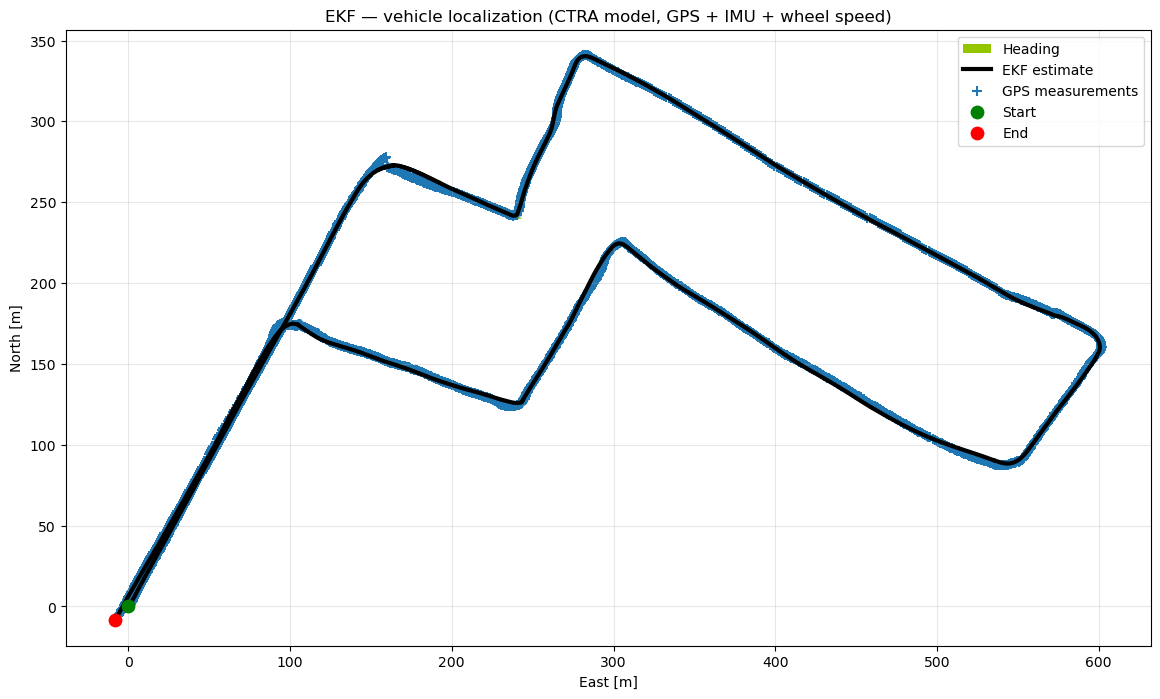

In [7]:
fig, ax_p = plt.subplots(figsize=(14, 8))

# EKF heading quivers (subsample so the plot isn't a wall of arrows)
step = max(1, n // 80)
ax_p.quiver(x_hist[::step, 0], x_hist[::step, 1],
            np.cos(x_hist[::step, 2]), np.sin(x_hist[::step, 2]),
            color="#94C600", units="xy", width=0.6, scale=0.15,
            label="Heading")

ax_p.plot(x_hist[:, 0], x_hist[:, 1], "k-", lw=3, label="EKF estimate")
ax_p.scatter(mx[::5], my[::5], s=50, c="C0", marker="+", label="GPS measurements")
ax_p.scatter(x_hist[0, 0],  x_hist[0, 1],  s=80, c="g", zorder=5, label="Start")
ax_p.scatter(x_hist[-1, 0], x_hist[-1, 1], s=80, c="r", zorder=5, label="End")

ax_p.set_xlabel("East [m]")
ax_p.set_ylabel("North [m]")
ax_p.set_title("EKF — vehicle localization (CTRA model, GPS + IMU + wheel speed)")
ax_p.set_aspect("equal", adjustable="datalim")
ax_p.grid(alpha=0.3)
ax_p.legend()
plt.show()
